# ECG Heartbeat Classification — Preprocessing
**Author:** Abdullah Al Noman Taki — VR528988
**University of Verona**


In [1]:
# ── 1. Imports ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from collections import Counter
print('Libraries imported!')

Libraries imported!


In [2]:
# ── 2. Download Dataset ───────────────────────────────────────────────────────
from google.colab import files
files.upload()  # upload kaggle.json
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d shayanfazeli/heartbeat --unzip
print('Dataset downloaded!')

Saving MIT-BIH Arrhythmia Database.zip to MIT-BIH Arrhythmia Database.zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/shayanfazeli/heartbeat
License(s): unknown
100% 98.8M/98.8M [00:00<00:00, 176MB/s]

Dataset downloaded!


In [3]:
# ── 3. Load CSV ───────────────────────────────────────────────────────────────
train_df = pd.read_csv('mitbih_train.csv', header=None)
test_df  = pd.read_csv('mitbih_test.csv',  header=None)
print('Train shape:', train_df.shape)
print('Test shape: ', test_df.shape)

Train shape: (87554, 188)
Test shape:  (21892, 188)


In [4]:
# ── 4. Split Features & Labels ───────────────────────────────────────────────
X_train_raw = train_df.iloc[:, :-1].values
y_train_raw = train_df.iloc[:, -1].values.astype(int)
X_test_raw  = test_df.iloc[:, :-1].values
y_test_raw  = test_df.iloc[:, -1].values.astype(int)

CLASS_NAMES = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print('X_train:', X_train_raw.shape)
print('X_test: ', X_test_raw.shape)

X_train: (87554, 187)
X_test:  (21892, 187)


=== Class Distribution (Train) ===
  Class 0 — Normal: 72471 (82.8%)
  Class 1 — Supraventricular: 2223 (2.5%)
  Class 2 — Ventricular: 5788 (6.6%)
  Class 3 — Fusion: 641 (0.7%)
  Class 4 — Unknown: 6431 (7.3%)


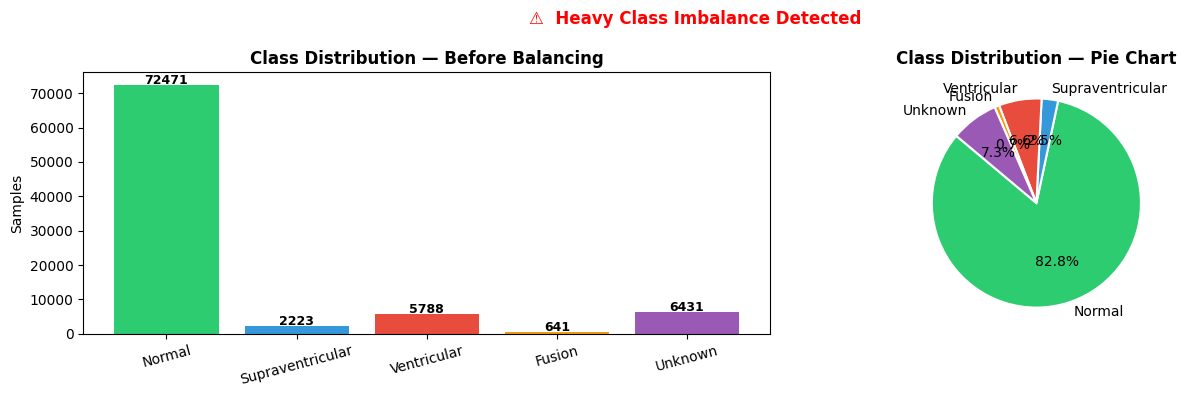


Imbalance ratio: 113:1 (Normal vs Fusion)


In [5]:
# ── 5. Class Distribution (Before Balancing) ─────────────────────────────────
counter = Counter(y_train_raw)
print('=== Class Distribution (Train) ===')
for cls, count in sorted(counter.items()):
    print(f'  Class {cls} — {CLASS_NAMES[cls]}: {count} ({count/len(y_train_raw)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
counts = [counter[i] for i in range(5)]
colors = ['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6']

bars = axes[0].bar(CLASS_NAMES, counts, color=colors)
axes[0].set_title('Class Distribution — Before Balancing', fontweight='bold')
axes[0].set_ylabel('Samples')
axes[0].tick_params(axis='x', rotation=15)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 str(count), ha='center', fontweight='bold', fontsize=9)

axes[1].pie(counts, labels=CLASS_NAMES, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Class Distribution — Pie Chart', fontweight='bold')

plt.suptitle('⚠️  Heavy Class Imbalance Detected', color='red', fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nImbalance ratio: {counter[0]/counter[3]:.0f}:1 (Normal vs Fusion)')

In [6]:
# ── 6. Balance Train & Test ───────────────────────────────────────────────────
TARGET_TRAIN = 3000
TARGET_TEST  = 300

def balance_dataset(X, y, target):
    X_list, y_list = [], []
    for cls in range(5):
        idx = np.where(y == cls)[0]
        X_cls, y_cls = resample(X[idx], y[idx],
                                 replace=len(idx) < target,
                                 n_samples=target, random_state=42)
        X_list.append(X_cls)
        y_list.append(y_cls)
    X_bal = np.vstack(X_list)
    y_bal = np.hstack(y_list)
    idx = np.random.permutation(len(X_bal))
    return X_bal[idx], y_bal[idx]

X_balanced, y_balanced = balance_dataset(X_train_raw, y_train_raw, TARGET_TRAIN)
X_test_bal, y_test_bal = balance_dataset(X_test_raw,  y_test_raw,  TARGET_TEST)

print(f'Balanced train: {X_balanced.shape} | counts: {Counter(y_balanced)}')
print(f'Balanced test:  {X_test_bal.shape}  | counts: {Counter(y_test_bal)}')

Balanced train: (15000, 187) | counts: Counter({np.int64(1): 3000, np.int64(4): 3000, np.int64(3): 3000, np.int64(0): 3000, np.int64(2): 3000})
Balanced test:  (1500, 187)  | counts: Counter({np.int64(0): 300, np.int64(3): 300, np.int64(4): 300, np.int64(2): 300, np.int64(1): 300})


In [7]:
# ── 7. Train/Val Split & Normalize ───────────────────────────────────────────
X_tr, X_val, y_tr, y_val = train_test_split(
    X_balanced, y_balanced,
    test_size=0.15, random_state=42, stratify=y_balanced
)

def normalize(X):
    mn = X.min(axis=1, keepdims=True)
    mx = X.max(axis=1, keepdims=True)
    return (X - mn) / (mx - mn + 1e-8)

X_tr   = normalize(X_tr)
X_val  = normalize(X_val)
X_test = normalize(X_test_bal)
y_test = y_test_bal

print(f'Train : {X_tr.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Train : (12750, 187) | Val: (2250, 187) | Test: (1500, 187)


Train: (12750, 187, 1)
Val:   (2250, 187, 1)
Test:  (1500, 187, 1)


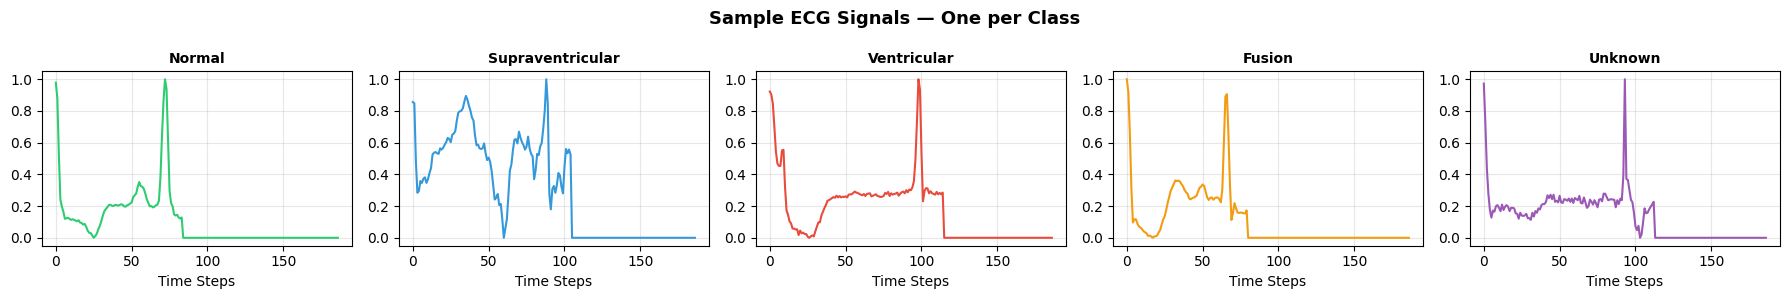

In [8]:
# ── 8. Reshape & Visualize ────────────────────────────────────────────────────
X_train_seq = X_tr.reshape(-1, 187, 1)
X_val_seq   = X_val.reshape(-1, 187, 1)
X_test_seq  = X_test.reshape(-1, 187, 1)

print('Train:', X_train_seq.shape)
print('Val:  ', X_val_seq.shape)
print('Test: ', X_test_seq.shape)

# Visualize one sample per class
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
colors = ['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6']
for cls in range(5):
    idx = np.where(y_tr == cls)[0][0]
    axes[cls].plot(X_tr[idx], color=colors[cls], linewidth=1.5)
    axes[cls].set_title(CLASS_NAMES[cls], fontweight='bold', fontsize=10)
    axes[cls].set_xlabel('Time Steps')
    axes[cls].grid(True, alpha=0.3)
plt.suptitle('Sample ECG Signals — One per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ecg_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── 9. Save to Google Drive ───────────────────────────────────────────────────
import os
from google.colab import drive
drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/ECG', exist_ok=True)

np.save('/content/drive/MyDrive/ECG/X_train_seq.npy', X_train_seq)
np.save('/content/drive/MyDrive/ECG/X_val_seq.npy',   X_val_seq)
np.save('/content/drive/MyDrive/ECG/X_test_seq.npy',  X_test_seq)
np.save('/content/drive/MyDrive/ECG/y_train.npy',     y_tr)
np.save('/content/drive/MyDrive/ECG/y_val.npy',       y_val)
np.save('/content/drive/MyDrive/ECG/y_test.npy',      y_test)

print('✅ Data saved to Google Drive!')
print(f'\n=== Final Summary ===')
print(f'Training   : {X_train_seq.shape[0]} samples')
print(f'Validation : {X_val_seq.shape[0]} samples')
print(f'Test       : {X_test_seq.shape[0]} samples')
print(f'Input shape: (187, 1)')
print(f'Classes    : 5')

Mounted at /content/drive
✅ Data saved to Google Drive!

=== Final Summary ===
Training   : 12750 samples
Validation : 2250 samples
Test       : 1500 samples
Input shape: (187, 1)
Classes    : 5
